<h1>Uso Quiotidiano</h1>
Si progetta uina parte di codice per verificare che data un'immagine standard si riesca a trovare i segnali all'interno di essa

<h2>Primo Metodo, divisione in sotto immagini</h2>
Col primo metodo quello che si vuole fare è suddividere l'immagine in tante sotto immagini, questo per poter capire se si riesce a rilevare un segnale stradale

In [29]:
import nbimporter
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO

from torchvision import transforms
import os


import python_file.dataclass as StreetSign
import python_file.function as Function
import python_file.network as Network

from python_file.dirPath import modelliDir, imageDir, Test, imageTest, yoloResult

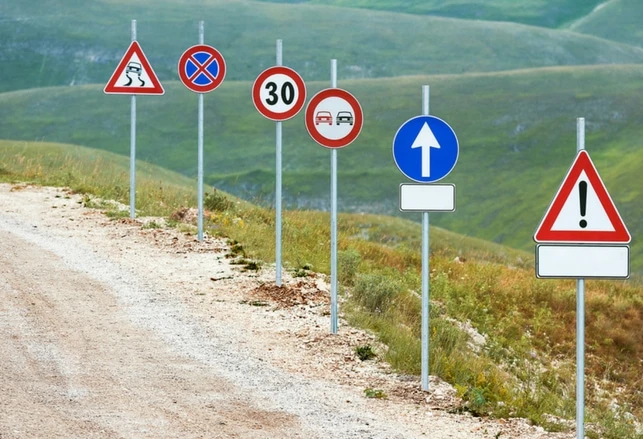

In [34]:
#target_img = '2046.png'
#img = Image.open(Test / target_img)
target_img = 'test.jpeg'
img = Image.open(imageTest / target_img)
img

In [35]:
model = Network.MiniAlexNetV2()
model.load_state_dict(torch.load(modelliDir / 'minialexnetV2_dataset-1200.pth'))
model.eval()

input_height = 32
input_width = 32

mean = 0.6529
std = 0.3422

preprocess = transforms.Compose([
    transforms.Resize((input_height, input_width)),
    transforms.ToTensor(),  # Converte l'immagine in un tensore PyTorch
    #transforms.Normalize(mean, std),
])

In [36]:


classi = {0: "Indicazione", 1: "Divieto", 2: "Pericolo", 3: "Background"}

# Leggi le annotazioni
with open(Test / 'prova.txt') as f:
    annotations = [line.strip().split() for line in f.readlines()]

# Per una specifica immagine (es. 0.png)
#target_img = '0.png'
#img = Image.open(Test / target_img)

for ann in annotations:
    if ann[0] == target_img:
        x1, y1, x2, y2 = int(ann[1]), int(ann[2]), int(ann[3]), int(ann[4])
        true_class = int(ann[5])
        
        # Ritaglia il segnale dall'immagine full-size
        crop = img.crop((x1, y1, x2, y2))
        
        # Visualizza il crop
        plt.imshow(crop)
        
        tensor = preprocess(crop).unsqueeze(0)[:, :3, :, :]
        
        with torch.no_grad():
            output = model(tensor)
            pred = output.argmax(dim=1).item()
        
        print(f"Segnale in ({x1},{y1})-({x2},{y2}): "
              f"Predetto={classi[pred]}, Reale={classi[true_class]}")

In [37]:
preprocess = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
])

classi = {0: "Indicazione", 1: "Divieto", 2: "Pericolo", 3: "Background"}

# Carica un'immagine full-size dal test
w, h = img.size

# Sliding window a diverse scale
results = []
for scale in [64, 96, 128, 160]:
    step = scale // 2  # overlap del 50%
    for y in range(0, h - scale, step):
        for x in range(0, w - scale, step):
            crop = img.crop((x, y, x + scale, y + scale))
            tensor = preprocess(crop).unsqueeze(0)[:, :3, :, :]
            
            with torch.no_grad():
                output = model(tensor)
                prob = torch.softmax(output, dim=1)
                conf, pred = prob.max(1)
            
            if pred.item() != 3 and conf.item() > 0.8:  # soglia di confidenza
                results.append((x, y, x+scale, y+scale, classi[pred.item()], conf.item()))

from torchvision.ops import nms

results_clean = ""

if len(results) > 0:
    boxes_tensor = torch.tensor([[r[0], r[1], r[2], r[3]] for r in results], dtype=torch.float)
    scores_tensor = torch.tensor([r[5] for r in results], dtype=torch.float)
    
    # NMS: iou_threshold = 0.3 → elimina box che si sovrappongono per più del 30%
    keep = nms(boxes_tensor, scores_tensor, iou_threshold=0.3)
    
    results_clean = [results[i] for i in keep.tolist()]
    print(f"Prima di NMS: {len(results)} — Dopo NMS: {len(results_clean)}")
    for r in results_clean:
        print(f"  [{r[4]}] ({r[0]},{r[1]})-({r[2]},{r[3]}) conf={r[5]:.3f}")

Prima di NMS: 1 — Dopo NMS: 1
  [Divieto] (160,32)-(224,96) conf=0.885


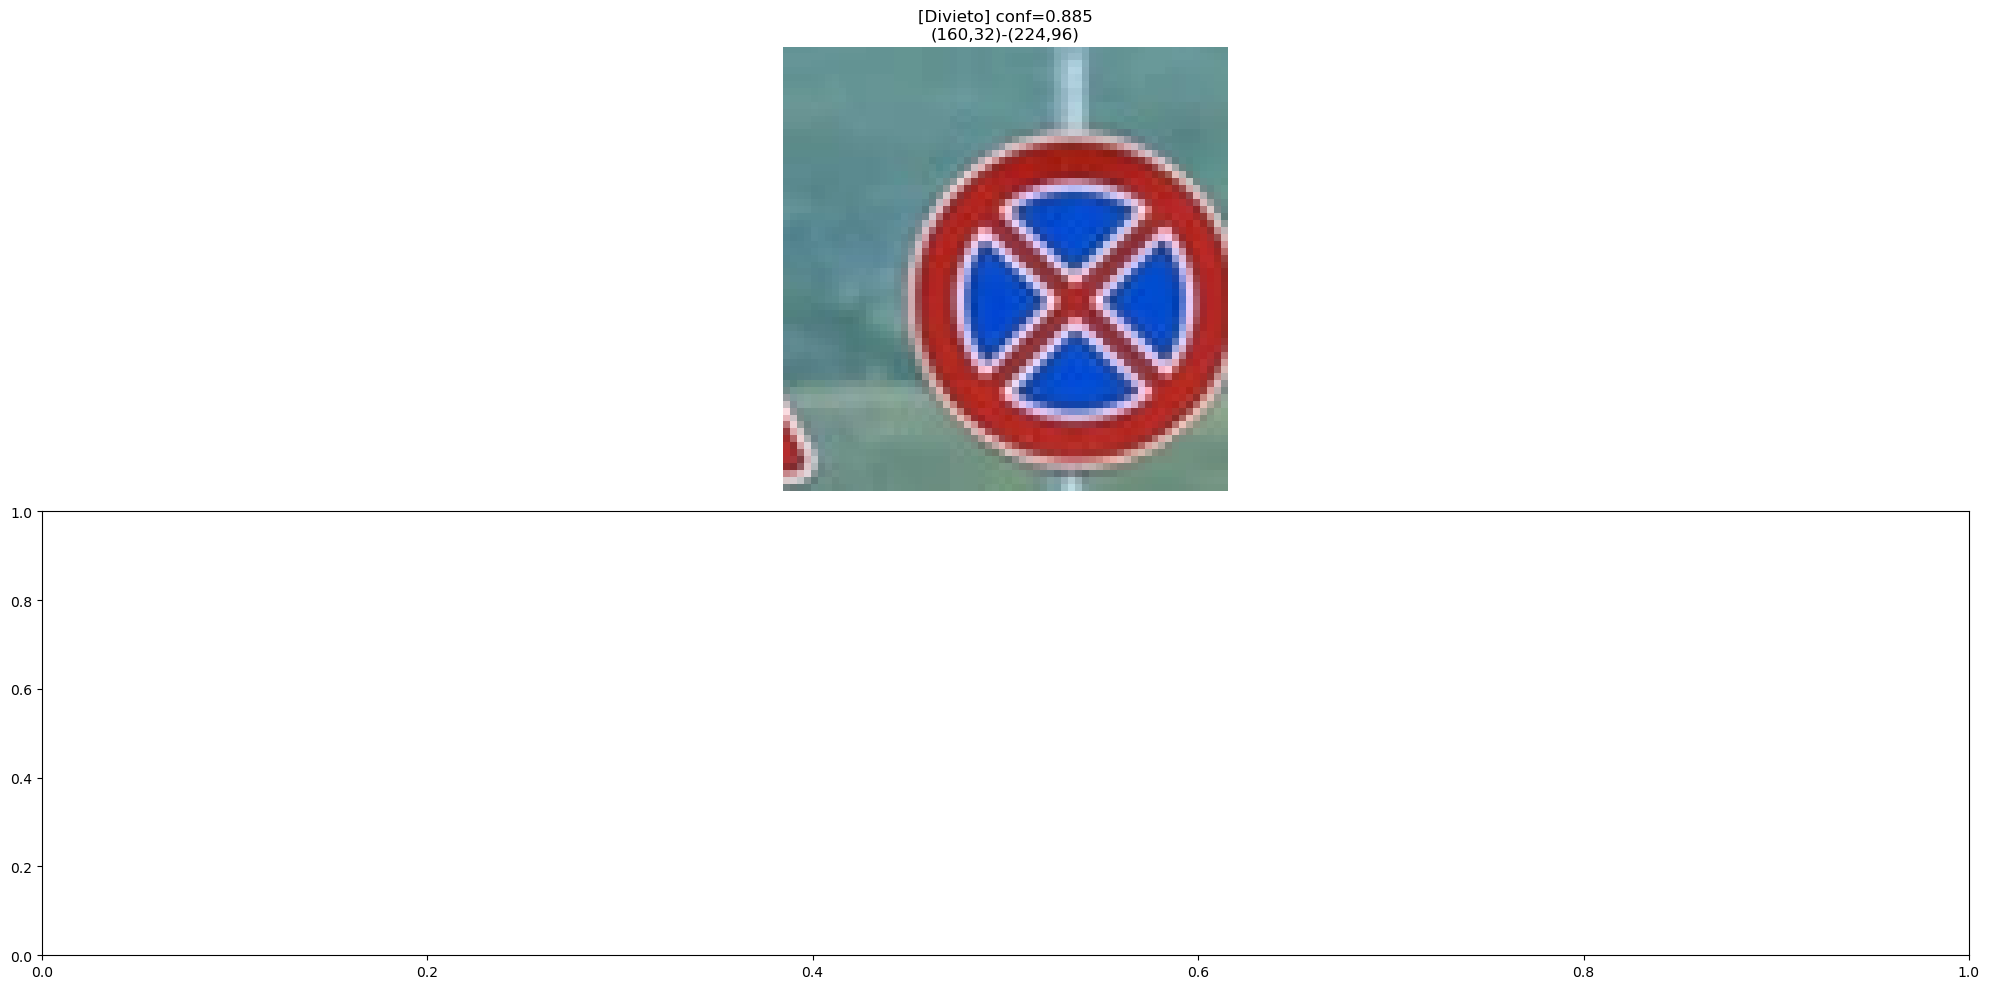

In [38]:
if len(results_clean) > 0:
    fig, axes = plt.subplots(2, len(results_clean)//2 + 1, figsize=(20, 10))
    axes = axes.flatten()
    
    for i, r in enumerate(results_clean):
        crop = img.crop((r[0], r[1], r[2], r[3]))
        
        # Visualizza il crop
        axes[i].imshow(crop)
        axes[i].set_title(f"[{r[4]}] conf={r[5]:.3f}\n({r[0]},{r[1]})-({r[2]},{r[3]})")
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

<H1>Test con YOLO</H1> 

In [23]:
%load_ext autoreload
%autoreload 2

import python_file.detect_and_classify as detect

detect.detect_and_classify(
        img_name= target_img,
        img_path= imageTest,
        cls_weights= modelliDir / 'minialexnetV2_dataset-1200.pth',)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload

0: 448x640 6 traffic_signs, 5.4ms
Speed: 1.2ms preprocess, 5.4ms inference, 0.8ms postprocess per image at shape (1, 3, 448, 640)
Risultato salvato in image/yolo/test.jpeg


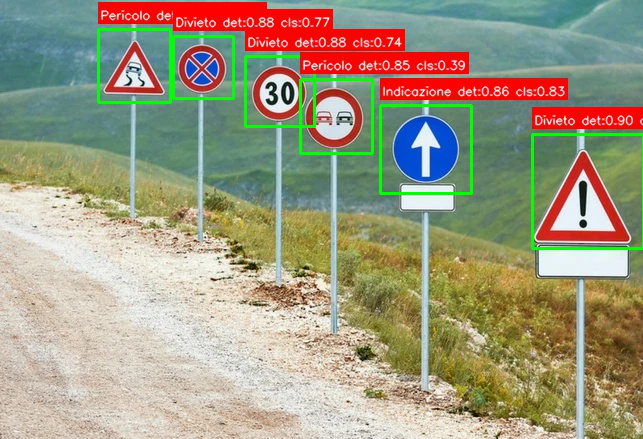

In [24]:
img = Image.open(yoloResult / target_img)
img